In [1]:
import sys
import os

sys.path.append('/scratch2/mrenaudin/colorlessgreenRNNs')

In [73]:
import torch
from torch.utils.data import Dataset, DataLoader
import tqdm
from src.language_models.dictionary_corpus import Dictionary, Corpus, tokenize
from src.language_models.model import RNNModel as lstm
from src.language_models.model import CBR_RNN as cbr
from src.language_models.utils import move_to_device
from torch.nn.functional import scaled_dot_product_attention
from evaluation_notebooks.utils import NounPPDataset, collate_fn_nounpp
import torch.nn as nn
import random
import pandas as pd
from collections import defaultdict
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm



In [74]:
batch_size = 1024
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_path = "/scratch2/mrenaudin/colorlessgreenRNNs/english_data"  # current directory
dictionary = Dictionary(data_path)
checkpoint_path = "/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/cbr2h128_shuffling/epoch_40.pt"  # Replace with your checkpoint path
nounpp = '//scratch2/mrenaudin/colorlessgreenRNNs/NounPP/Stimuli/nounpp.txt'
dataset = NounPPDataset(nounpp, dictionary)
dataloader = DataLoader(dataset, batch_size=batch_size, collate_fn=collate_fn_nounpp)

## Load model

In [4]:
class CBR_RNN(nn.Module):
    # goal here is to reuse CBR_RNN but with scaled dot product attention for more efficient computations.
    # Also I got rid of options such as loading pretrained embeddings, and ablating attention to simplify the code.
    # In the future if those options are needed, they can still be copy pasted from William's code as the structure hasn't changed
    def __init__(self, ntoken, ninp, nhid, nheads, dropout=0.5, device=None):
        super().__init__()
        # same layers as Timkey
        self.device = device
        self.nheads = nheads
        self.tanh = nn.Tanh()
        self.drop = nn.Dropout(dropout)
        self.score_attn = nn.Softmax(dim=-1)
        self.encoder = nn.Embedding(ntoken, ninp)
        self.q = nn.Linear(ninp + nhid, nhid)
        self.intermediate_h = nn.Linear(nhid * 4, nhid * 4)
        self.decoder = nn.Linear(nhid, ntoken)
        self.q_norm = torch.nn.LayerNorm(nhid)
        self.int_norm = torch.nn.LayerNorm(nhid * 4)
        self.f_norm = torch.nn.LayerNorm(nhid * 3)
        self.nhid = nhid
        self.final_h = nn.Linear(nhid * 4, nhid * 3)
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=nhid, num_heads=nheads, batch_first=True
        )

        self.init_weights()

    def init_weights(self):
        """Initialize model weights for better training dynamics"""
        # General initialization
        for name, param in self.named_parameters():
            if "weight" in name:
                if "norm" in name:
                    nn.init.ones_(param)
                elif "encoder" in name:
                    nn.init.normal_(param, mean=0, std=0.01)
                elif "decoder" in name:
                    nn.init.normal_(param, mean=0, std=0.01)
                else:
                    # Standard He initialization for processing layers
                    nn.init.kaiming_normal_(param, mode="fan_in", nonlinearity="tanh")
            elif "bias" in name:
                nn.init.zeros_(param)

    def init_cache(self, observation, nheads):
        """Initialize hidden state and attention caches with better initialization strategy"""
        if len(observation.size()) > 1:
            bsz = observation.size(dim=-1)
        else:
            bsz = 1

        hidden = torch.zeros(1, bsz, self.nhid).to(self.device) 
        if nheads == 1:
            key_cache = torch.zeros(bsz, 1, 1, self.nhid).to(self.device) 
            value_cache = torch.zeros(bsz, 1, 1, self.nhid).to(self.device) 
        else:
            key_cache = torch.zeros(bsz, 1, self.nhid).to(self.device) 
            value_cache = torch.zeros(bsz, 1, self.nhid).to(self.device) 
        return hidden, key_cache, value_cache


    def update_cache(self, key_cache, value_cache, hidden, key_cache_i, value_cache_i, hidden_i, nheads):
        hidden_i = hidden_i.unsqueeze(0)
        hidden = torch.cat((hidden, hidden_i), dim=0)
        if nheads == 1:
                key_cache_i = key_cache_i.unsqueeze(1).unsqueeze(1)
                value_cache_i = value_cache_i.unsqueeze(1).unsqueeze(1)
                key_cache = torch.cat((key_cache, key_cache_i), dim=2)
                value_cache = torch.cat((value_cache, value_cache_i), dim=2)
        else:
            key_cache_i = key_cache_i.unsqueeze(1)
            value_cache_i = value_cache_i.unsqueeze(1)
            key_cache = torch.cat((key_cache, key_cache_i), dim=1)
            value_cache = torch.cat((value_cache, value_cache_i), dim=1)
            
        return key_cache, value_cache, hidden
    
    @staticmethod
    def temperature_attention(query, key, value, temperature, gumbel_softmax=None, attn_mask=None,dropout_p=0.0,
        is_causal=False, scale=None, enable_gqa=False) -> torch.Tensor:
        L, S = query.size(-2), key.size(-2)
        scale_factor = 1 / math.sqrt(query.size(-1)) if scale is None else scale
        attn_bias = torch.zeros(L, S, dtype=query.dtype, device=query.device)
        if is_causal:
            assert attn_mask is None
            temp_mask = torch.ones(L, S, dtype=torch.bool).tril(diagonal=0)
            attn_bias.masked_fill_(temp_mask.logical_not(), float("-inf"))
            attn_bias.to(query.dtype)

        if attn_mask is not None:
            if attn_mask.dtype == torch.bool:
                attn_bias.masked_fill_(attn_mask.logical_not(), float("-inf"))
            else:
                attn_bias = attn_mask + attn_bias

        if enable_gqa:
            key = key.repeat_interleave(query.size(-3)//key.size(-3), -3)
            value = value.repeat_interleave(query.size(-3)//value.size(-3), -3)

        attn_weight = query @ key.transpose(-2, -1) * scale_factor
        attn_weight += attn_bias
        if gumbel_softmax: 
            attn_weight = torch.gumbel_softmax(attn_weight, tau=temperature, hard=False, dim=-1)
        else : 
            attn_weight = attn_weight/temperature
            attn_weight = torch.softmax(attn_weight, dim=-1)
        attn_weight = torch.dropout(attn_weight, dropout_p, train=True)
        return attn_weight @ value
    
    def attention_layer(self, query, key_cache, value_cache, nheads, temperature, gumbel_softmax):
        if nheads == 1 :
                query = query.unsqueeze(1)
                
                # Ensure all tensors are on the same device
                if query.device != key_cache.device:
                    key_cache = key_cache.to(query.device)
                if query.device != value_cache.device:
                    value_cache = value_cache.to(query.device)
                if temperature is None:  
                    try:
                        attn_output = scaled_dot_product_attention(
                            query, key_cache, value_cache, is_causal=False
                        )
                    except Exception as e:
                        logging.error(f"Error in attention computation: {str(e)}")
                        raise
                    attn = attn_output.squeeze(1).squeeze(1)
                    del attn_output  # No longer needed after squeezing
                    query = query.squeeze(1).squeeze(1)
                else:
                    try:
                        attn_output = self.temperature_attention(
                            query, key_cache, value_cache, temperature, is_causal=False
                        )
                    except Exception as e:
                        logging.error(f"Error in attention computation: {str(e)}")
                        raise
                    attn = attn_output.squeeze(1).squeeze(1)
                    del attn_output  # No longer needed after squeezing
                    query = query.squeeze(1).squeeze(1)

            
        else:
            attn_output, _ = self.multihead_attn(
                query, key_cache, value_cache, is_causal=False
            )
            attn = attn_output.squeeze(1)
            del attn_output  # No longer needed after squeezing
            query = query.squeeze(1)
            
        return attn, query
    
    def intermediate_layers(self, i, emb, query, attn, hidden):
        intermediate_input = torch.cat((emb[i], query, attn, hidden[-1]), -1)
        del query, attn  
        intermediate = self.drop(
            self.tanh(self.int_norm(self.intermediate_h(intermediate_input)))
        )
        del intermediate_input  
        final_output = self.drop(self.tanh(self.f_norm(self.final_h(intermediate))))
        del intermediate  
        key_cache_i, value_cache_i, hidden_i = final_output.split(self.nhid, dim=-1)
        del final_output
        return key_cache_i, value_cache_i, hidden_i
    
    def get_query(self, emb, hidden):
        combined = torch.cat((emb, hidden[-1]), -1)
        query = self.drop(self.tanh(self.q_norm(self.q(combined))))
        del combined  # No longer needed after creating query
        query = query.unsqueeze(1)
        return query
    
    def forward(self, observation, initial_cache, nheads, temperature, gumbel_softmax, replace):
        seq_len = observation.size(0)
        hidden, key_cache, value_cache = initial_cache

        # 1. Encode observations
        emb = self.drop(self.encoder(observation))
        del observation  # No longer needed after encoding
        
        for i in range(seq_len):
            # 2. Concatenate with previous hidden state
            
            
            query = self.get_query(emb[i], hidden)
            
            attn, query = self.attention_layer(query, key_cache, value_cache, nheads, temperature, gumbel_softmax)
            if replace == 'hidden' and i==seq_len -1 :
                hidden_replaced = torch.zeros_like(hidden)
                key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb, query, attn, hidden_replaced)
            elif replace == 'attention' and i==seq_len -1 :
                attention_replaced = torch.zeros_like(attn)
                key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb, query, attention_replaced, hidden)
            elif replace == 'query' and i==seq_len -1 :
                query_replaced = torch.zeros_like(query)
                key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb, query_replaced, attn, hidden)
            elif replace == 'emb' and i==seq_len -1 :
                emb_replaced = torch.zeros_like(emb)
                key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb_replaced, query, attn, hidden)
            else :
                key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb, query, attn, hidden)
            
            key_cache, value_cache, hidden = self.update_cache(key_cache, value_cache, hidden, key_cache_i, value_cache_i, hidden_i, nheads)
            
            del key_cache_i, value_cache_i, hidden_i  # No longer needed after concatenation

        decoded = self.decoder(hidden[1:])

        return decoded, hidden

## Evaluate

In [115]:
class CBR_RNN(nn.Module):
    # goal here is to reuse CBR_RNN but with scaled dot product attention for more efficient computations.
    # Also I got rid of options such as loading pretrained embeddings, and ablating attention to simplify the code.
    # In the future if those options are needed, they can still be copy pasted from William's code as the structure hasn't changed
    def __init__(self, ntoken, ninp, nhid, nheads, dropout=0.5, device=None):
        super().__init__()
        # same layers as Timkey
        self.device = device
        self.nheads = nheads
        self.tanh = nn.Tanh()
        self.drop = nn.Dropout(dropout)
        self.score_attn = nn.Softmax(dim=-1)
        self.encoder = nn.Embedding(ntoken, ninp)
        self.q = nn.Linear(ninp + nhid, nhid)
        self.intermediate_h = nn.Linear(nhid * 4, nhid * 4)
        self.decoder = nn.Linear(nhid, ntoken)
        self.q_norm = torch.nn.LayerNorm(nhid)
        self.int_norm = torch.nn.LayerNorm(nhid * 4)
        self.f_norm = torch.nn.LayerNorm(nhid * 3)
        self.nhid = nhid
        self.final_h = nn.Linear(nhid * 4, nhid * 3)
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=nhid, num_heads=nheads, batch_first=True
        )

        self.init_weights()

    def init_weights(self):
        """Initialize model weights for better training dynamics"""
        # General initialization
        for name, param in self.named_parameters():
            if "weight" in name:
                if "norm" in name:
                    nn.init.ones_(param)
                elif "encoder" in name:
                    nn.init.normal_(param, mean=0, std=0.01)
                elif "decoder" in name:
                    nn.init.normal_(param, mean=0, std=0.01)
                else:
                    # Standard He initialization for processing layers
                    nn.init.kaiming_normal_(param, mode="fan_in", nonlinearity="tanh")
            elif "bias" in name:
                nn.init.zeros_(param)

    def init_cache(self, observation, nheads):
        """Initialize hidden state and attention caches with better initialization strategy"""
        if len(observation.size()) > 1:
            bsz = observation.size(dim=-1)
        else:
            bsz = 1

        hidden = torch.zeros(1, bsz, self.nhid).to(self.device) 
        if nheads == 1:
            key_cache = torch.zeros(bsz, 1, 1, self.nhid).to(self.device) 
            value_cache = torch.zeros(bsz, 1, 1, self.nhid).to(self.device) 
        else:
            key_cache = torch.zeros(bsz, 1, self.nhid).to(self.device) 
            value_cache = torch.zeros(bsz, 1, self.nhid).to(self.device) 
        return hidden, key_cache, value_cache


    def update_cache(self, key_cache, value_cache, hidden, key_cache_i, value_cache_i, hidden_i, nheads):
        hidden_i = hidden_i.unsqueeze(0)
        hidden = torch.cat((hidden, hidden_i), dim=0)
        if nheads == 1:
                key_cache_i = key_cache_i.unsqueeze(1).unsqueeze(1)
                value_cache_i = value_cache_i.unsqueeze(1).unsqueeze(1)
                key_cache = torch.cat((key_cache, key_cache_i), dim=2)
                value_cache = torch.cat((value_cache, value_cache_i), dim=2)
        else:
            key_cache_i = key_cache_i.unsqueeze(1)
            value_cache_i = value_cache_i.unsqueeze(1)
            key_cache = torch.cat((key_cache, key_cache_i), dim=1)
            value_cache = torch.cat((value_cache, value_cache_i), dim=1)
            
        return key_cache, value_cache, hidden
    
    @staticmethod
    def temperature_attention(query, key, value, temperature, gumbel_softmax=None, attn_mask=None,dropout_p=0.0,
        is_causal=False, scale=None, enable_gqa=False) -> torch.Tensor:
        L, S = query.size(-2), key.size(-2)
        scale_factor = 1 / math.sqrt(query.size(-1)) if scale is None else scale
        attn_bias = torch.zeros(L, S, dtype=query.dtype, device=query.device)
        if is_causal:
            assert attn_mask is None
            temp_mask = torch.ones(L, S, dtype=torch.bool).tril(diagonal=0)
            attn_bias.masked_fill_(temp_mask.logical_not(), float("-inf"))
            attn_bias.to(query.dtype)

        if attn_mask is not None:
            if attn_mask.dtype == torch.bool:
                attn_bias.masked_fill_(attn_mask.logical_not(), float("-inf"))
            else:
                attn_bias = attn_mask + attn_bias

        if enable_gqa:
            key = key.repeat_interleave(query.size(-3)//key.size(-3), -3)
            value = value.repeat_interleave(query.size(-3)//value.size(-3), -3)

        attn_weight = query @ key.transpose(-2, -1) * scale_factor
        attn_weight += attn_bias
        if gumbel_softmax: 
            attn_weight = torch.gumbel_softmax(attn_weight, tau=temperature, hard=False, dim=-1)
        else : 
            attn_weight = attn_weight/temperature
            attn_weight = torch.softmax(attn_weight, dim=-1)
        attn_weight = torch.dropout(attn_weight, dropout_p, train=True)
        return attn_weight @ value
    
    def attention_layer(self, query, key_cache, value_cache, nheads, temperature, gumbel_softmax):
        if nheads == 1 :
                query = query.unsqueeze(1)
                
                # Ensure all tensors are on the same device
                if query.device != key_cache.device:
                    key_cache = key_cache.to(query.device)
                if query.device != value_cache.device:
                    value_cache = value_cache.to(query.device)
                if temperature is None:  
                    try:
                        attn_output = scaled_dot_product_attention(
                            query, key_cache, value_cache, is_causal=False
                        )
                    except Exception as e:
                        logging.error(f"Error in attention computation: {str(e)}")
                        raise
                    attn = attn_output.squeeze(1).squeeze(1)
                    del attn_output  # No longer needed after squeezing
                    query = query.squeeze(1).squeeze(1)
                else:
                    try:
                        attn_output = self.temperature_attention(
                            query, key_cache, value_cache, temperature, is_causal=False
                        )
                    except Exception as e:
                        logging.error(f"Error in attention computation: {str(e)}")
                        raise
                    attn = attn_output.squeeze(1).squeeze(1)
                    del attn_output  # No longer needed after squeezing
                    query = query.squeeze(1).squeeze(1)

            
        else:
            attn_output, _ = self.multihead_attn(
                query, key_cache, value_cache, is_causal=False
            )
            attn = attn_output.squeeze(1)
            del attn_output  # No longer needed after squeezing
            query = query.squeeze(1)
            
        return attn, query
    
    def intermediate_layers(self, i, emb, query, attn, hidden):
        intermediate_input = torch.cat((emb[i], query, attn, hidden[-1]), -1)
        del query, attn  
        intermediate = self.drop(
            self.tanh(self.int_norm(self.intermediate_h(intermediate_input)))
        )
        del intermediate_input  
        final_output = self.drop(self.tanh(self.f_norm(self.final_h(intermediate))))
        del intermediate  
        key_cache_i, value_cache_i, hidden_i = final_output.split(self.nhid, dim=-1)
        del final_output
        return key_cache_i, value_cache_i, hidden_i
    
    def get_query(self, emb, hidden):
        combined = torch.cat((emb, hidden[-1]), -1)
        query = self.drop(self.tanh(self.q_norm(self.q(combined))))
        del combined  # No longer needed after creating query
        query = query.unsqueeze(1)
        return query
    
    def forward(self, observation, initial_cache, nheads, temperature, gumbel_softmax, replace):
        seq_len = observation.size(0)
        hidden, key_cache, value_cache = initial_cache

        # 1. Encode observations
        emb = self.drop(self.encoder(observation))
        del observation  # No longer needed after encoding
        
        for i in range(seq_len):
            # 2. Concatenate with previous hidden state
            if replace =='subject_hidden' and i==seq_len-1:
                new_hidden = hidden
                new_hidden[1,:,:]=0
                query = self.get_query(emb[i], new_hidden)
                
            else:
            
                query = self.get_query(emb[i], hidden)
            print(hidden.shape)
            if replace=='subject_value' and i == seq_len -1 :#since the model is processing attractor to predict subject, impossible to ablate attractor value
                new_value = value_cache
                new_value[:,:,2,:]=0
                print('new value', new_value.shape)
                attn, query = self.attention_layer(query, key_cache, new_value, nheads, temperature, gumbel_softmax)
            
            else :  
                attn, query = self.attention_layer(query, key_cache, value_cache, nheads, temperature, gumbel_softmax)
            if replace == 'hidden' and i==seq_len -1 :
                hidden_replaced = torch.zeros_like(hidden)
                key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb, query, attn, hidden_replaced)
            elif replace == 'attention' and i==seq_len -1 :
                attention_replaced = torch.zeros_like(attn)
                key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb, query, attention_replaced, hidden)
            elif replace == 'query' and i==seq_len -1 :
                query_replaced = torch.zeros_like(query)
                key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb, query_replaced, attn, hidden)
            elif replace == 'emb' and i==seq_len -1 :
                emb_replaced = torch.zeros_like(emb)
                key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb_replaced, query, attn, hidden)
            else :
                key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb, query, attn, hidden)
            
            key_cache, value_cache, hidden = self.update_cache(key_cache, value_cache, hidden, key_cache_i, value_cache_i, hidden_i, nheads)
            
            del key_cache_i, value_cache_i, hidden_i  # No longer needed after concatenation

        decoded = self.decoder(hidden[1:])

        return decoded, hidden

In [116]:
for j in range(1,7):
    print(j)

1
2
3
4
5
6


In [117]:
model = CBR_RNN(ntoken=50001, ninp=650, nhid=650, device=device, nheads=1)
check = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/test_attention_650/epoch_38.pt', map_location='cpu')
model.load_state_dict(check['model_state_dict'])
temp = check['epoch']


In [118]:
def eval(model, test_dataloader, temperature, replace):
    condition_accuracies = defaultdict(int)
    condition_counts = defaultdict(int)
    correct_pred = 0
    sentence_details = []
    model.eval()
    # Forward pass with hidden state update word by word
    with torch.no_grad():
        for batch in test_dataloader:
            out = None
            written = batch["sentence"]
            sentence = batch["encoded_sentence"]
            correct = batch["encoded_correct"]
            wrong = batch["encoded_wrong"]
            condition = batch["condition"]
            batch_size = sentence.size(0)

            sent = sentence[:, :5].transpose(0, 1)
            cache = model.init_cache(sent,1)  # regarder si on peut mettre du priming
            # for i in range(sent.shape[1]):
            out, cache = model(sent, cache, 1, temperature, True, replace)
            log_probs = torch.nn.functional.log_softmax(
                out, dim=-1
            )  # s(out.squeeze(0))
            # déja sur correct et wrong log probs, pas les même résultats que sur extract_predictions.py
            correct_log_probs = log_probs[
                -1, torch.arange(batch_size), correct
            ]  # Shape: [512]
            wrong_log_probs = log_probs[-1, torch.arange(batch_size), wrong]
            correct_predictions = correct_log_probs >= wrong_log_probs

            for i in range(batch_size):
                cond = condition[i]
                pred = correct_predictions[i].item()  # Convert tensor to Python boolean
                condition_counts[cond] += 1
                condition_accuracies[cond] += pred

                sentence_details.append(
                    {
                        "sentence": written[i],
                        "condition": condition[i],
                        "correct_log_prob": correct_log_probs[i],
                        "wrong_log_prob": wrong_log_probs[i],
                        "model_prefers_correct": pred,
                    }
                )

    final_accuracies = {
        cond: condition_accuracies[cond] / condition_counts[cond]
        for cond in condition_accuracies
    }
    return final_accuracies

In [119]:
replace = ['subject_value', 'attractor_value', None]
replace = ['subject_value', None]
results = {}
for r in replace:
    results[r]=eval(model, dataloader, temp, r)

torch.Size([1, 1024, 650])
torch.Size([2, 1024, 650])
torch.Size([3, 1024, 650])
torch.Size([4, 1024, 650])
torch.Size([5, 1024, 650])
new value torch.Size([1024, 1, 5, 650])
torch.Size([1, 1024, 650])
torch.Size([2, 1024, 650])
torch.Size([3, 1024, 650])
torch.Size([4, 1024, 650])
torch.Size([5, 1024, 650])
new value torch.Size([1024, 1, 5, 650])
torch.Size([1, 1024, 650])
torch.Size([2, 1024, 650])
torch.Size([3, 1024, 650])
torch.Size([4, 1024, 650])
torch.Size([5, 1024, 650])
new value torch.Size([1024, 1, 5, 650])
torch.Size([1, 928, 650])
torch.Size([2, 928, 650])
torch.Size([3, 928, 650])
torch.Size([4, 928, 650])
torch.Size([5, 928, 650])
new value torch.Size([928, 1, 5, 650])
torch.Size([1, 1024, 650])
torch.Size([2, 1024, 650])
torch.Size([3, 1024, 650])
torch.Size([4, 1024, 650])
torch.Size([5, 1024, 650])
torch.Size([1, 1024, 650])
torch.Size([2, 1024, 650])
torch.Size([3, 1024, 650])
torch.Size([4, 1024, 650])
torch.Size([5, 1024, 650])
torch.Size([1, 1024, 650])
torch.Siz

In [84]:
replace = ['hidden', 'attention', 'query', 'emb', None]
results = {}
for r in replace:
    results[r]=eval(model, dataloader, temp, r)
    break
    

torch.Size([1024, 1, 1, 650])
torch.Size([1024, 1, 2, 650])
torch.Size([1024, 1, 3, 650])
torch.Size([1024, 1, 4, 650])
torch.Size([1024, 1, 5, 650])
torch.Size([1024, 1, 1, 650])
torch.Size([1024, 1, 2, 650])
torch.Size([1024, 1, 3, 650])
torch.Size([1024, 1, 4, 650])
torch.Size([1024, 1, 5, 650])
torch.Size([1024, 1, 1, 650])
torch.Size([1024, 1, 2, 650])
torch.Size([1024, 1, 3, 650])
torch.Size([1024, 1, 4, 650])
torch.Size([1024, 1, 5, 650])
torch.Size([928, 1, 1, 650])
torch.Size([928, 1, 2, 650])
torch.Size([928, 1, 3, 650])
torch.Size([928, 1, 4, 650])
torch.Size([928, 1, 5, 650])


In [114]:
results

{'subject_value': {'singular singular': 0.862,
  'singular plural': 0.497,
  'plural singular': 0.844,
  'plural plural': 0.82},
 None: {'singular singular': 0.87,
  'singular plural': 0.499,
  'plural singular': 0.855,
  'plural plural': 0.828}}

In [106]:
results

{'subject_value': {'singular singular': 0.853,
  'singular plural': 0.503,
  'plural singular': 0.868,
  'plural plural': 0.825},
 'attractor_value': {'singular singular': 0.878,
  'singular plural': 0.458,
  'plural singular': 0.863,
  'plural plural': 0.854},
 None: {'singular singular': 0.87,
  'singular plural': 0.499,
  'plural singular': 0.855,
  'plural plural': 0.828}}

In [11]:
df = pd.DataFrame(results)

# Step 2: Identify baseline key (None or "None")
baseline_key = None if None in df.columns else "None"

# Step 3: Compute differences
df_diff = df.subtract(df[baseline_key], axis=0)

# Step 4: Add baseline row back as is
df_diff[baseline_key] = df[baseline_key]

# Step 5: Transpose (rows become columns and vice versa)
df_diff = df_diff.T

# Step 6: Optional reordering for clarity
order = ['hidden', 'attention', 'query', 'emb', None]
df_diff = df_diff.loc[[key for key in order if key in df_diff.index]]

# Final Output
print(df_diff)

           singular singular  singular plural  plural singular  plural plural
hidden                -0.001           -0.127            0.003          0.023
attention             -0.053           -0.385           -0.504          0.087
query                 -0.015           -0.077            0.006          0.061
emb                    0.004            0.358            0.086          0.059
None                   0.870            0.499            0.855          0.828


# Evaluate on memory

In [4]:
class CBR_RNN(nn.Module):
    # goal here is to reuse CBR_RNN but with scaled dot product attention for more efficient computations.
    # Also I got rid of options such as loading pretrained embeddings, and ablating attention to simplify the code.
    # In the future if those options are needed, they can still be copy pasted from William's code as the structure hasn't changed
    def __init__(self, ntoken, ninp, nhid, nheads, dropout=0.5, device=None):
        super().__init__()
        # same layers as Timkey
        self.device = device
        self.nheads = nheads
        self.tanh = nn.Tanh()
        self.drop = nn.Dropout(dropout)
        self.score_attn = nn.Softmax(dim=-1)
        self.encoder = nn.Embedding(ntoken, ninp)
        self.q = nn.Linear(ninp + nhid, nhid)
        self.intermediate_h = nn.Linear(nhid * 4, nhid * 4)
        self.decoder = nn.Linear(nhid, ntoken)
        self.q_norm = torch.nn.LayerNorm(nhid)
        self.int_norm = torch.nn.LayerNorm(nhid * 4)
        self.f_norm = torch.nn.LayerNorm(nhid * 3)
        self.nhid = nhid
        self.final_h = nn.Linear(nhid * 4, nhid * 3)
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=nhid, num_heads=nheads, batch_first=True
        )

        self.init_weights()

    def init_weights(self):
        """Initialize model weights for better training dynamics"""
        # General initialization
        for name, param in self.named_parameters():
            if "weight" in name:
                if "norm" in name:
                    nn.init.ones_(param)
                elif "encoder" in name:
                    nn.init.normal_(param, mean=0, std=0.01)
                elif "decoder" in name:
                    nn.init.normal_(param, mean=0, std=0.01)
                else:
                    # Standard He initialization for processing layers
                    nn.init.kaiming_normal_(param, mode="fan_in", nonlinearity="tanh")
            elif "bias" in name:
                nn.init.zeros_(param)

    def init_cache(self, observation, nheads):
        """Initialize hidden state and attention caches with better initialization strategy"""
        if len(observation.size()) > 1:
            bsz = observation.size(dim=-1)
        else:
            bsz = 1

        hidden = torch.zeros(1, bsz, self.nhid).to(self.device) 
        if nheads == 1:
            key_cache = torch.zeros(bsz, 1, 1, self.nhid).to(self.device) 
            value_cache = torch.zeros(bsz, 1, 1, self.nhid).to(self.device) 
        else:
            key_cache = torch.zeros(bsz, 1, self.nhid).to(self.device) 
            value_cache = torch.zeros(bsz, 1, self.nhid).to(self.device) 
        return hidden, key_cache, value_cache


    def update_cache(self, key_cache, value_cache, hidden, key_cache_i, value_cache_i, hidden_i, nheads):
        hidden_i = hidden_i.unsqueeze(0)
        hidden = torch.cat((hidden, hidden_i), dim=0)
        if nheads == 1:
                key_cache_i = key_cache_i.unsqueeze(1).unsqueeze(1)
                value_cache_i = value_cache_i.unsqueeze(1).unsqueeze(1)
                key_cache = torch.cat((key_cache, key_cache_i), dim=2)
                value_cache = torch.cat((value_cache, value_cache_i), dim=2)
        else:
            key_cache_i = key_cache_i.unsqueeze(1)
            value_cache_i = value_cache_i.unsqueeze(1)
            key_cache = torch.cat((key_cache, key_cache_i), dim=1)
            value_cache = torch.cat((value_cache, value_cache_i), dim=1)
            
        return key_cache, value_cache, hidden
    
    @staticmethod
    def temperature_attention(query, key, value, temperature, gumbel_softmax=None, attn_mask=None,dropout_p=0.0,
        is_causal=False, scale=None, enable_gqa=False) -> torch.Tensor:
        L, S = query.size(-2), key.size(-2)
        scale_factor = 1 / math.sqrt(query.size(-1)) if scale is None else scale
        attn_bias = torch.zeros(L, S, dtype=query.dtype, device=query.device)
        if is_causal:
            assert attn_mask is None
            temp_mask = torch.ones(L, S, dtype=torch.bool).tril(diagonal=0)
            attn_bias.masked_fill_(temp_mask.logical_not(), float("-inf"))
            attn_bias.to(query.dtype)

        if attn_mask is not None:
            if attn_mask.dtype == torch.bool:
                attn_bias.masked_fill_(attn_mask.logical_not(), float("-inf"))
            else:
                attn_bias = attn_mask + attn_bias

        if enable_gqa:
            key = key.repeat_interleave(query.size(-3)//key.size(-3), -3)
            value = value.repeat_interleave(query.size(-3)//value.size(-3), -3)

        attn_weight = query @ key.transpose(-2, -1) * scale_factor
        attn_weight += attn_bias
        if gumbel_softmax: 
            attn_weight = torch.gumbel_softmax(attn_weight, tau=temperature, hard=False, dim=-1)
        else : 
            attn_weight = attn_weight/temperature
            attn_weight = torch.softmax(attn_weight, dim=-1)
        attn_weight = torch.dropout(attn_weight, dropout_p, train=True)
        return attn_weight @ value
    
    def attention_layer(self, query, key_cache, value_cache, nheads, temperature, gumbel_softmax):
        if nheads == 1 :
                query = query.unsqueeze(1)
                
                # Ensure all tensors are on the same device
                if query.device != key_cache.device:
                    key_cache = key_cache.to(query.device)
                if query.device != value_cache.device:
                    value_cache = value_cache.to(query.device)
                if temperature is None:  
                    try:
                        attn_output = scaled_dot_product_attention(
                            query, key_cache, value_cache, is_causal=False
                        )
                    except Exception as e:
                        logging.error(f"Error in attention computation: {str(e)}")
                        raise
                    attn = attn_output.squeeze(1).squeeze(1)
                    del attn_output  # No longer needed after squeezing
                    query = query.squeeze(1).squeeze(1)
                else:
                    try:
                        attn_output = self.temperature_attention(
                            query, key_cache, value_cache, temperature, is_causal=False
                        )
                    except Exception as e:
                        logging.error(f"Error in attention computation: {str(e)}")
                        raise
                    attn = attn_output.squeeze(1).squeeze(1)
                    del attn_output  # No longer needed after squeezing
                    query = query.squeeze(1).squeeze(1)

            
        else:
            attn_output, _ = self.multihead_attn(
                query, key_cache, value_cache, is_causal=False
            )
            attn = attn_output.squeeze(1)
            del attn_output  # No longer needed after squeezing
            query = query.squeeze(1)
            
        return attn, query
    
    def intermediate_layers(self, i, emb, query, attn, hidden):
        intermediate_input = torch.cat((emb[i], query, attn, hidden[-1]), -1)
        del query, attn  
        intermediate = self.drop(
            self.tanh(self.int_norm(self.intermediate_h(intermediate_input)))
        )
        del intermediate_input  
        final_output = self.drop(self.tanh(self.f_norm(self.final_h(intermediate))))
        del intermediate  
        key_cache_i, value_cache_i, hidden_i = final_output.split(self.nhid, dim=-1)
        del final_output
        return key_cache_i, value_cache_i, hidden_i
    
    def get_query(self, emb, hidden):
        combined = torch.cat((emb, hidden[-1]), -1)
        query = self.drop(self.tanh(self.q_norm(self.q(combined))))
        del combined  # No longer needed after creating query
        query = query.unsqueeze(1)
        return query
    
    def forward(self, observation, initial_cache, nheads, temperature, gumbel_softmax, replace, list_len):
        seq_len = observation.size(0)
        hidden, key_cache, value_cache = initial_cache

        # 1. Encode observations
        emb = self.drop(self.encoder(observation))
        del observation  # No longer needed after encoding
        
        for i in range(seq_len):
            # 2. Concatenate with previous hidden state
            
            
            query = self.get_query(emb[i], hidden)
            
            attn, query = self.attention_layer(query, key_cache, value_cache, nheads, temperature, gumbel_softmax)
            if replace == 'hidden' and i in range(1,list_len+1) :
                hidden_replaced = torch.zeros_like(hidden)
                key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb, query, attn, hidden_replaced)
            elif replace == 'attention' and i in range(1,list_len+1) :
                attention_replaced = torch.zeros_like(attn)
                key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb, query, attention_replaced, hidden)
            elif replace == 'query' and i in range(1,list_len+1) :
                query_replaced = torch.zeros_like(query)
                key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb, query_replaced, attn, hidden)
            elif replace == 'emb' and i in range(1,list_len+1) :
                emb_replaced = torch.zeros_like(emb)
                key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb_replaced, query, attn, hidden)
            else :
                key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb, query, attn, hidden)
            
            key_cache, value_cache, hidden = self.update_cache(key_cache, value_cache, hidden, key_cache_i, value_cache_i, hidden_i, nheads)
            
            del key_cache_i, value_cache_i, hidden_i  # No longer needed after concatenation

        decoded = self.decoder(hidden[1:])

        return decoded, hidden

In [5]:
from wm_tests.utils import WMTestDataset, collate_fn
import torch.nn.functional as F
model = CBR_RNN(ntoken=50001, ninp=650, nhid=650, device=device, nheads=1)
check = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/test_attention_650/epoch_17.pt', map_location='cpu')
model.load_state_dict(check['model_state_dict'])
temp = check['epoch']
sentence_path = '/scratch2/mrenaudin/colorlessgreenRNNs/wm_tests/rnn_input_files/categorized_lists_sce1_repeat.txt'
marker_path = '/scratch2/mrenaudin/colorlessgreenRNNs/wm_tests/rnn_input_files/categorized_lists_sce1_repeat_markers.txt'
data_path = "/scratch2/mrenaudin/colorlessgreenRNNs/english_data"
dictionary = Dictionary(data_path)
wm_dataset = WMTestDataset(sentence_path, marker_path, dictionary)
dataloader = DataLoader(wm_dataset, batch_size=230, collate_fn=collate_fn)



In [6]:
def eval(model, dataloader, nheads, temperature, gs, replace):
    all_repeat_surprisals = {}
    model.eval()
    # Forward pass with hidden state update word by word
    with torch.no_grad():
        for batch in dataloader:
            out = None
            list1 = batch["list1"]
            encoded_sentence = batch["encoded_sentence"]
            condition = batch["condition"]
            marker = batch["marker"]
            batch_size, seq_len = encoded_sentence.shape
            input_seq = encoded_sentence[:, :-1].transpose(0, 1)  # (seq_len-1, batch_size)
            target_seq = encoded_sentence[:, 1:].transpose(0, 1)
            cache = model.init_cache(input_seq, 1)
            output, hidden = model(input_seq, cache, nheads, temperature, gs, replace, condition[0][0]*2)
            log_probs = F.log_softmax(output, dim=-1)  # shape (seq_len-1, batch_size, vocab_size)
            
            nll_loss = F.nll_loss(
                        log_probs.reshape(-1, log_probs.size(-1)),  # ( (seq_len-1)*batch_size, vocab_size )
                        target_seq.reshape(-1),                         # ((seq_len-1)*batch_size)
                        reduction='none'
                    )
                    
                    # Reshape back to (seq_len-1, batch_size)
            nll_loss = nll_loss.view(seq_len - 1, batch_size).transpose(0, 1)  # (batch_size, seq_len-1)        
            mask_list1 = (marker[:, 1:] == 1)  # remove first token since nll_loss aligns with shifted target
            mask_list2 = (marker[:, 1:] == 3)
            
            # Extract surprisal for each list and reshape
            # Number of tokens in each list should be condition[0][0]*2 (including punctuation)
            list_len = condition[0][0] * 2
            
            surprisal_list1 = nll_loss[mask_list1].view(batch_size, list_len)
            surprisal_list2 = nll_loss[mask_list2].view(batch_size, list_len)
            
            # Select repeated word indices (odd positions assuming repeats are at odd indices)
            word_indices = torch.arange(0, condition[0][0]*2, step=2)  # e.g., 1, 3, 5, ...
            word_indices = word_indices[1:]#get rid of first word of the list
            # print(word_indices)
            # for i in word_indices:
            #     words_at_indices = list1[0][i]
            #     print(words_at_indices)
            surprisal1_repeats = surprisal_list1[:, word_indices]
            surprisal2_repeats = surprisal_list2[:, word_indices]
            
            # Compute repeat surprisal ratio as percentage
            repeat_surprisal = (surprisal2_repeats / surprisal1_repeats) * 100
            all_repeat_surprisals[f'list len : {condition[0][0]}, prompt len : {condition[0][1]}']=repeat_surprisal
        
    return all_repeat_surprisals
        

In [7]:
replace = ['hidden', 'attention', 'query', 'emb', None]
results = {}
for r in replace:
    results[r]=eval(model, dataloader,1,  temp, True, r)

In [8]:
results['hidden'].keys()

dict_keys(['list len : 3, prompt len : 1', 'list len : 5, prompt len : 1', 'list len : 7, prompt len : 1', 'list len : 10, prompt len : 1', 'list len : 3, prompt len : 2', 'list len : 5, prompt len : 2', 'list len : 7, prompt len : 2', 'list len : 10, prompt len : 2', 'list len : 3, prompt len : 3', 'list len : 5, prompt len : 3', 'list len : 7, prompt len : 3', 'list len : 10, prompt len : 3', 'list len : 3, prompt len : 4', 'list len : 5, prompt len : 4', 'list len : 7, prompt len : 4', 'list len : 10, prompt len : 4', 'list len : 3, prompt len : 5', 'list len : 5, prompt len : 5', 'list len : 7, prompt len : 5', 'list len : 10, prompt len : 5'])

In [9]:
results
res = {}
for r in replace:
    res[r]= results[r]['list len : 3, prompt len : 5']

In [10]:
median_res = {k: v.flatten().median().item() for k, v in res.items()}
median_res

{'hidden': 172.35235595703125,
 'attention': 171.93661499023438,
 'query': 172.77137756347656,
 'emb': 172.84779357910156,
 None: 171.6438446044922}

In [11]:
for key in median_res.keys():
    print(key)
    print(median_res[None]- median_res[key])

hidden
-0.7085113525390625
attention
-0.2927703857421875
query
-1.127532958984375
emb
-1.203948974609375
None
0.0


In [219]:
90.73095703125-88.66511535644531

2.0658416748046875

# Visualizing attention for each case

In [12]:
class CBR_RNN(nn.Module):
    # goal here is to reuse CBR_RNN but with scaled dot product attention for more efficient computations.
    # Also I got rid of options such as loading pretrained embeddings, and ablating attention to simplify the code.
    # In the future if those options are needed, they can still be copy pasted from William's code as the structure hasn't changed
    def __init__(self, ntoken, ninp, nhid, nheads, dropout=0.5, device=None):
        super().__init__()
        # same layers as Timkey
        self.device = device
        self.nheads = nheads
        self.tanh = nn.Tanh()
        self.drop = nn.Dropout(dropout)
        self.score_attn = nn.Softmax(dim=-1)
        self.encoder = nn.Embedding(ntoken, ninp)
        self.q = nn.Linear(ninp + nhid, nhid)
        self.intermediate_h = nn.Linear(nhid * 4, nhid * 4)
        self.decoder = nn.Linear(nhid, ntoken)
        self.q_norm = torch.nn.LayerNorm(nhid)
        self.int_norm = torch.nn.LayerNorm(nhid * 4)
        self.f_norm = torch.nn.LayerNorm(nhid * 3)
        self.nhid = nhid
        self.final_h = nn.Linear(nhid * 4, nhid * 3)
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=nhid, num_heads=nheads, batch_first=True
        )

        self.init_weights()

    def init_weights(self):
        """Initialize model weights for better training dynamics"""
        # General initialization
        for name, param in self.named_parameters():
            if "weight" in name:
                if "norm" in name:
                    nn.init.ones_(param)
                elif "encoder" in name:
                    nn.init.normal_(param, mean=0, std=0.01)
                elif "decoder" in name:
                    nn.init.normal_(param, mean=0, std=0.01)
                else:
                    # Standard He initialization for processing layers
                    nn.init.kaiming_normal_(param, mode="fan_in", nonlinearity="tanh")
            elif "bias" in name:
                nn.init.zeros_(param)

    def init_cache(self, observation, nheads):
        """Initialize hidden state and attention caches with better initialization strategy"""
        if len(observation.size()) > 1:
            bsz = observation.size(dim=-1)
        else:
            bsz = 1

        hidden = torch.zeros(1, bsz, self.nhid).to(self.device) 
        if nheads == 1:
            key_cache = torch.zeros(bsz, 1, 1, self.nhid).to(self.device) 
            value_cache = torch.zeros(bsz, 1, 1, self.nhid).to(self.device) 
        else:
            key_cache = torch.zeros(bsz, 1, self.nhid).to(self.device) 
            value_cache = torch.zeros(bsz, 1, self.nhid).to(self.device) 
        return hidden, key_cache, value_cache


    def update_cache(self, key_cache, value_cache, hidden, key_cache_i, value_cache_i, hidden_i, nheads):
        hidden_i = hidden_i.unsqueeze(0)
        hidden = torch.cat((hidden, hidden_i), dim=0)
        if nheads == 1:
                key_cache_i = key_cache_i.unsqueeze(1).unsqueeze(1)
                value_cache_i = value_cache_i.unsqueeze(1).unsqueeze(1)
                key_cache = torch.cat((key_cache, key_cache_i), dim=2)
                value_cache = torch.cat((value_cache, value_cache_i), dim=2)
        else:
            key_cache_i = key_cache_i.unsqueeze(1)
            value_cache_i = value_cache_i.unsqueeze(1)
            key_cache = torch.cat((key_cache, key_cache_i), dim=1)
            value_cache = torch.cat((value_cache, value_cache_i), dim=1)
            
        return key_cache, value_cache, hidden
    
    @staticmethod
    def temperature_attention(query, key, value, temperature, gumbel_softmax=None, attn_mask=None,dropout_p=0.0,
        is_causal=False, scale=None, enable_gqa=False) -> torch.Tensor:
        L, S = query.size(-2), key.size(-2)
        scale_factor = 1 / math.sqrt(query.size(-1)) if scale is None else scale
        attn_bias = torch.zeros(L, S, dtype=query.dtype, device=query.device)
        if is_causal:
            assert attn_mask is None
            temp_mask = torch.ones(L, S, dtype=torch.bool).tril(diagonal=0)
            attn_bias.masked_fill_(temp_mask.logical_not(), float("-inf"))
            attn_bias.to(query.dtype)

        if attn_mask is not None:
            if attn_mask.dtype == torch.bool:
                attn_bias.masked_fill_(attn_mask.logical_not(), float("-inf"))
            else:
                attn_bias = attn_mask + attn_bias

        if enable_gqa:
            key = key.repeat_interleave(query.size(-3)//key.size(-3), -3)
            value = value.repeat_interleave(query.size(-3)//value.size(-3), -3)

        attn_weight = query @ key.transpose(-2, -1) * scale_factor
        attn_weight += attn_bias
        if gumbel_softmax: 
            attn_weight = torch.gumbel_softmax(attn_weight, tau=temperature, hard=False, dim=-1)
        else : 
            attn_weight = attn_weight/temperature
            attn_weight = torch.softmax(attn_weight, dim=-1)
        attn_weight = torch.dropout(attn_weight, dropout_p, train=True)
        return attn_weight, attn_weight @ value
    
    def attention_layer(self, query, key_cache, value_cache, nheads, temperature, gumbel_softmax):
        if nheads == 1:
                query = query.unsqueeze(1)
                
                # Ensure all tensors are on the same device
                if query.device != key_cache.device:
                    key_cache = key_cache.to(query.device)
                if query.device != value_cache.device:
                    value_cache = value_cache.to(query.device)
                if temperature==1:  
                    try:
                        attn_output = scaled_dot_product_attention(
                            query, key_cache, value_cache, is_causal=False
                        )
                    except Exception as e:
                        logging.error(f"Error in attention computation: {str(e)}")
                        raise
                    attn = attn_output.squeeze(1).squeeze(1)
                    del attn_output  # No longer needed after squeezing
                    query = query.squeeze(1).squeeze(1)
                else:
                    try:
                        attn_weight, attn_output = self.temperature_attention(
                            query, key_cache, value_cache, temperature, is_causal=False
                        )
                    except Exception as e:
                        logging.error(f"Error in attention computation: {str(e)}")
                        raise
                    attn = attn_output.squeeze(1).squeeze(1)
                    del attn_output  # No longer needed after squeezing
                    query = query.squeeze(1).squeeze(1)

            
        else:
            attn_output, _ = self.multihead_attn(
                query, key_cache, value_cache, is_causal=False
            )
            attn = attn_output.squeeze(1)
            del attn_output  # No longer needed after squeezing
            query = query.squeeze(1)
            
        return attn_weight, attn, query
    
    def intermediate_layers(self, i, emb, query, attn, hidden):
        intermediate_input = torch.cat((emb[i], query, attn, hidden[-1]), -1)
        del query, attn  
        intermediate = self.drop(
            self.tanh(self.int_norm(self.intermediate_h(intermediate_input)))
        )
        del intermediate_input  
        final_output = self.drop(self.tanh(self.f_norm(self.final_h(intermediate))))
        del intermediate  
        key_cache_i, value_cache_i, hidden_i = final_output.split(self.nhid, dim=-1)
        del final_output
        return key_cache_i, value_cache_i, hidden_i
    
    def get_query(self, emb, hidden):
        combined = torch.cat((emb, hidden[-1]), -1)
        query = self.drop(self.tanh(self.q_norm(self.q(combined))))
        del combined  # No longer needed after creating query
        query = query.unsqueeze(1)
        return query
    
    def forward(self, observation, initial_cache, nheads, temperature, gumbel_softmax):
        seq_len = observation.size(0)
        hidden, key_cache, value_cache = initial_cache

        # 1. Encode observations
        emb = self.drop(self.encoder(observation))
        del observation  # No longer needed after encoding
        attn_weights = []
        attns = []
        for i in range(seq_len):
            # 2. Concatenate with previous hidden state

            
            query = self.get_query(emb[i], hidden)
            
            attn_weight, attn, query = self.attention_layer(query, key_cache, value_cache, nheads, temperature, gumbel_softmax)
            attn_weights.append(attn_weight)
            attns.append(attn)
            key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb, query, attn, hidden)
            
            key_cache, value_cache, hidden = self.update_cache(key_cache, value_cache, hidden, key_cache_i, value_cache_i, hidden_i, nheads)
            
            del key_cache_i, value_cache_i, hidden_i  # No longer needed after concatenation

        decoded = self.decoder(hidden[1:])

        return decoded, hidden, attn_weights, attns

In [13]:
def eval(model, test_dataloader, temperature):
    condition_accuracies = defaultdict(int)
    condition_counts = defaultdict(int)
    correct_pred = 0
    sentence_details = []
    model.eval()
    # Forward pass with hidden state update word by word
    with torch.no_grad():
        for batch in test_dataloader:
            out = None
            written = batch["sentence"]
            sentence = batch["encoded_sentence"]
            correct = batch["encoded_correct"]
            wrong = batch["encoded_wrong"]
            condition = batch["condition"]
            batch_size = sentence.size(0)

            sent = sentence.transpose(0, 1)
            cache = model.init_cache(sent,1)  # regarder si on peut mettre du priming
            # for i in range(sent.shape[1]):
            out, cache, attn_weights, attns = model(sent, cache, 1, temperature, True)
            log_probs = torch.nn.functional.log_softmax(
                out, dim=-1
            )  # s(out.squeeze(0))
            # déja sur correct et wrong log probs, pas les même résultats que sur extract_predictions.py
            correct_log_probs = log_probs[
                -1, torch.arange(batch_size), correct
            ]  # Shape: [512]
            wrong_log_probs = log_probs[-1, torch.arange(batch_size), wrong]
            correct_predictions = correct_log_probs >= wrong_log_probs

            for i in range(batch_size):
                cond = condition[i]
                pred = correct_predictions[i].item()  # Convert tensor to Python boolean
                condition_counts[cond] += 1
                condition_accuracies[cond] += pred

                sentence_details.append(
                    {
                        "sentence": written[i],
                        "condition": condition[i],
                        "correct_log_prob": correct_log_probs[i],
                        "wrong_log_prob": wrong_log_probs[i],
                        "model_prefers_correct": pred,
                    }
                )

    final_accuracies = {
        cond: condition_accuracies[cond] / condition_counts[cond]
        for cond in condition_accuracies
    }
    return final_accuracies, attn_weights, attns,  written

In [14]:
def get_one_sample_per_condition(dataset):
    seen_conditions = set()
    indices = []
    for i, cond in enumerate(dataset.conditions):
        if cond not in seen_conditions:
            seen_conditions.add(cond)
            indices.append(i)  # just the index, NOT a dict
    return indices


In [15]:
conditions = get_one_sample_per_condition(dataset)

In [16]:
def evaluate_one_sample_per_condition(dataset, model, temperature, replace, collate_fn):
    results = {}
    attention_weights = {}
    attention = {}
    sentences = {}

    one_sample_indices = get_one_sample_per_condition(dataset)
    for i in one_sample_indices:
        cond = dataset.conditions[i]
        cond_dataset = torch.utils.data.Subset(dataset, [i])
        cond_loader = DataLoader(cond_dataset, batch_size=1, collate_fn=collate_fn)

        cond_accuracy, attn_weights, attns, written = eval(model, cond_loader, temperature)
        results[cond] = cond_accuracy.get(cond, 0.0)
        attention_weights[cond]=attn_weights
        attention[cond]=attns
        sentences[cond]=written

    return results, attention, attention_weights, sentences

In [17]:
dataset = NounPPDataset(nounpp, dictionary)
model = CBR_RNN(ntoken=50001, ninp=650, nhid=650, device=device, nheads=1)
check = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/test_attention_650/epoch_38.pt', map_location='cpu')
model.load_state_dict(check['model_state_dict'])
temp = check['epoch']

In [39]:
temp

0.1188502227437019

In [18]:
res, attention, attention_weights, sentences = evaluate_one_sample_per_condition(dataset, model, temp, None, collate_fn_nounpp)

In [19]:
def create_attention_matrix(attention, condition):
    att_matrix = torch.zeros((len(attention[condition]), len(attention[condition])))  # 50 x 50

    for t in range(len(attention[condition])):
        att_t = attention[condition][t].squeeze()  # shape: (t+1,)
        att_matrix[t, :t+1] = att_t
    return att_matrix

In [130]:
att_ss = create_attention_matrix(attn, 'singular singular')

In [20]:
sentences['singular singular']

[['The', 'athlete', 'behind', 'the', 'bike', 'observes']]

In [26]:
def plot_heatmap(att_matrix, sentence, title):
    

    # Example data (replace with your actual data)
    att_matrix_np = att_matrix.numpy()  # Shape: [seq_len, seq_len]
    tokens = sentence  # Your list of tokens, length seq_len + 1 (make sure sizes match)

    # If att_matrix_np shape is smaller than tokens length,
    # slice tokens to match matrix size, or vice versa:
    tokens = tokens[:att_matrix_np.shape[0]]
    print

    fig, ax = plt.subplots(figsize=(6, 6))

    # Plot the heatmap
    cax = ax.matshow(att_matrix_np, cmap='gist_rainbow', vmin=0, vmax=1)

    # Set ticks and labels
    ax.set_xticks(np.arange(len(tokens)))
    ax.set_yticks(np.arange(len(tokens)))

    ax.set_xticklabels(tokens, rotation=90, fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)

    # Add colorbar
    fig.colorbar(cax, label='Attention Weight')

    ax.set_xlabel('Key (attended word)')
    ax.set_ylabel('Query (current word)')
    ax.set_title(f'{title}')

    plt.tight_layout()
    plt.show()


In [43]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def create_weighted_attention_matrix(attention_weights, values, condition):
    """
    attention_weights[condition]: list of tensors (one per timestep), each shape [t+1] or [seq_len]
    values[condition]: tensor shape [seq_len, value_dim]
    
    Returns a (seq_len, seq_len) matrix of weighted value norms.
    """
    seq_len = len(attention_weights[condition])
    value_dim = values[condition].shape[1]
    
    att_matrix = torch.zeros((seq_len, seq_len))  # final matrix to plot
    
    for t in range(seq_len):
        # attention weights at query t: shape [t+1]
        att_w_t = attention_weights[condition][t].squeeze()  # (t+1,)
        
        # corresponding values for keys 0..t: shape [t+1, value_dim]
        val_t = values[condition][:t+1, :]
        
        # weighted values: multiply weights by each vector
        weighted_vals = att_w_t.unsqueeze(1) * val_t  # shape [t+1, value_dim]
        
        # reduce to scalar per key: use L2 norm
        weighted_norms = torch.norm(weighted_vals, dim=1)  # shape [t+1]
        
        # place in matrix row t, columns 0..t
        att_matrix[t, :t+1] = weighted_norms
        
    return att_matrix

def plot_heatmap(att_matrix, sentence, title, n_bins=10):
    att_matrix_np = att_matrix.numpy()
    tokens = sentence[:att_matrix_np.shape[0]]
    
    bounds = np.linspace(0, 1, n_bins + 1)  # e.g., [0.0, 0.2, 0.4, ..., 1.0]
    cmap = ListedColormap(plt.get_cmap('viridis')(np.linspace(0, 1, n_bins)))
    norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N, clip=True)


    fig, ax = plt.subplots(figsize=(8, 8))
    cax = ax.matshow(att_matrix_np, cmap=cmap, norm=norm)

    ax.set_xticks(np.arange(len(tokens)))
    ax.set_yticks(np.arange(len(tokens)))

    ax.set_xticklabels(tokens, rotation=90, fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)

    fig.colorbar(cax, label='Weighted Attention Norm')

    ax.set_xlabel('Key (attended word)')
    ax.set_ylabel('Query (current word)')
    ax.set_title(title)

    plt.tight_layout()
    plt.show()


In [44]:
attention['singular singular'][0].shape

torch.Size([1, 650])

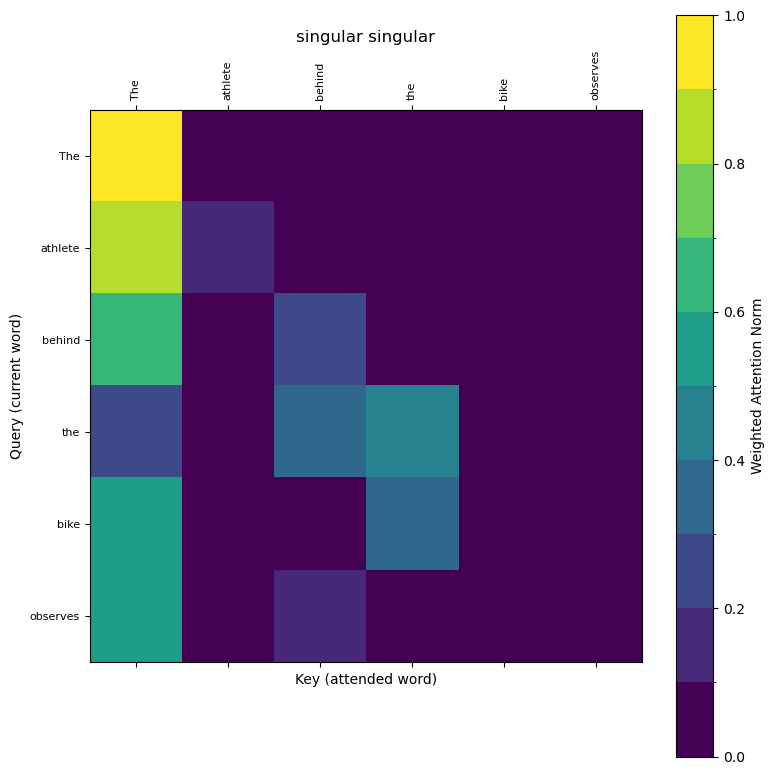

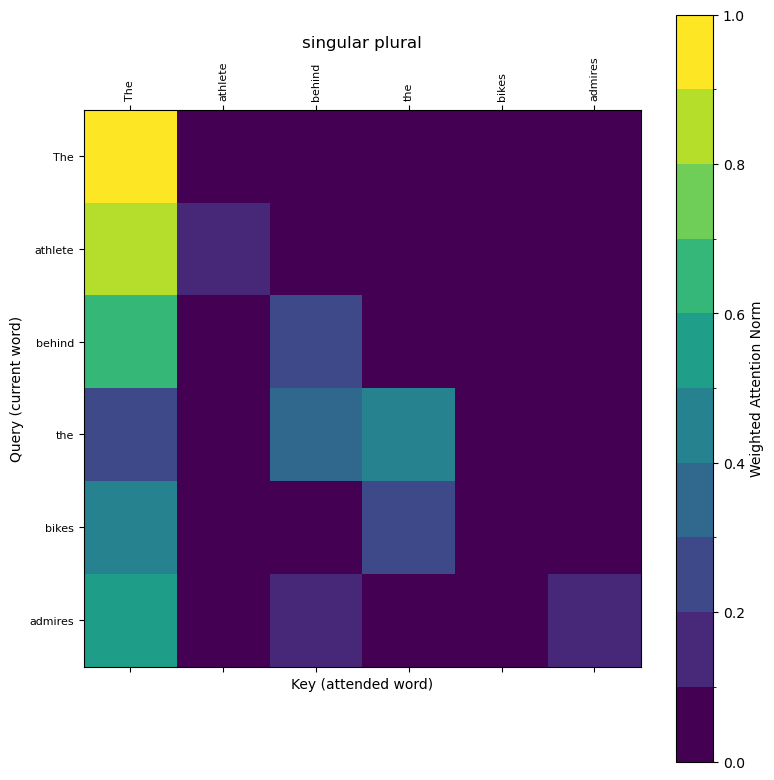

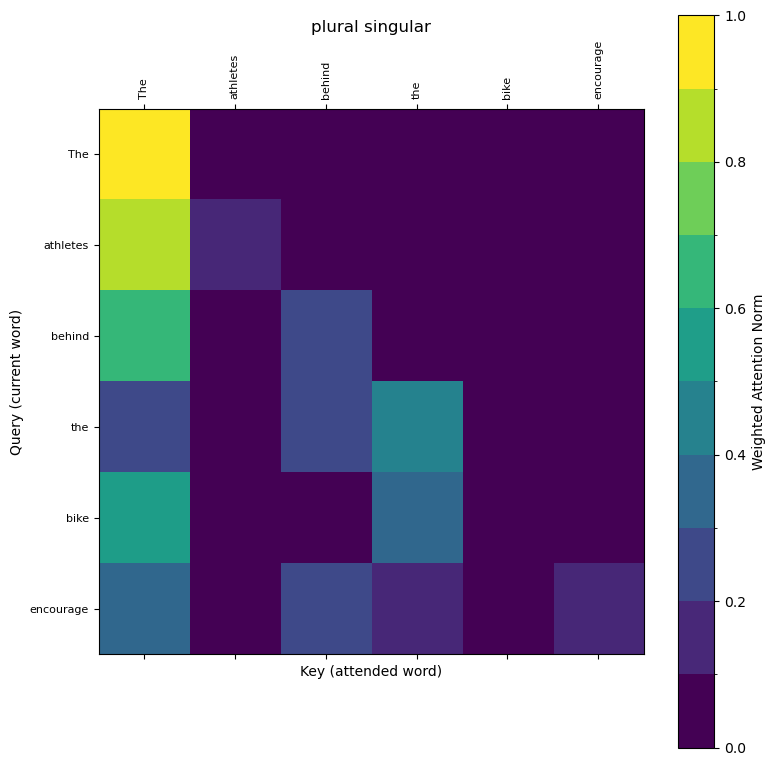

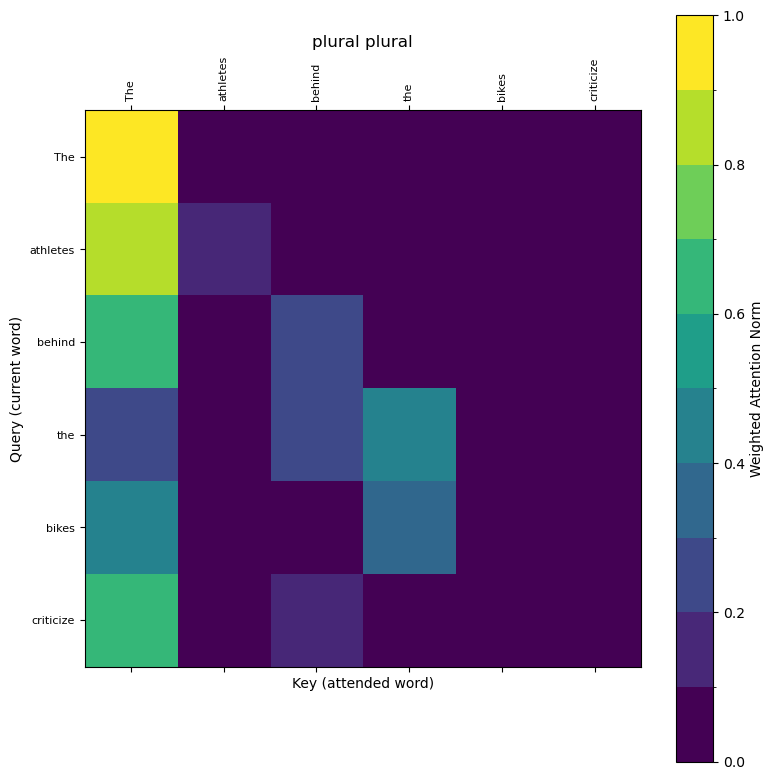

In [45]:
conditions = ['singular singular', 'singular plural', 'plural singular', 'plural plural']
for cond in conditions:
    att_mat = create_attention_matrix(attention_weights, cond)
    plot_heatmap(att_mat, sentences[cond][0], cond)
    # att_mat = create_attention_matrix(attention, cond)
    # plot_heatmap(att_mat, sentences[cond][0], cond)
    # break

In [127]:
subject_idx = 1
attractor_idx = 4
verb_idx = 5
conditions = ['singular singular', 'singular plural', 'plural singular', 'plural plural']
for cond in conditions:
    att_mat = create_attention_matrix(attn, cond)
    att_to_subject = att_mat[verb_idx, subject_idx].item()
    att_to_attractor = att_mat[verb_idx, attractor_idx].item()
    plot_heatmap(att_mat, sentences[cond][0])




In [46]:
from collections import defaultdict

attn_subject = defaultdict(list)
attn_attractor = defaultdict(list)

for cond in conditions:
    tokens = sentences[cond][0]  # unpack list of list
    att_matrix = create_attention_matrix(attention_weights, cond)  # your attention matrices dict

    att_to_subject = att_matrix[5, 1].item()
    att_to_attractor = att_matrix[5, 4].item()

    attn_subject[cond].append(att_to_subject)
    attn_attractor[cond].append(att_to_attractor)


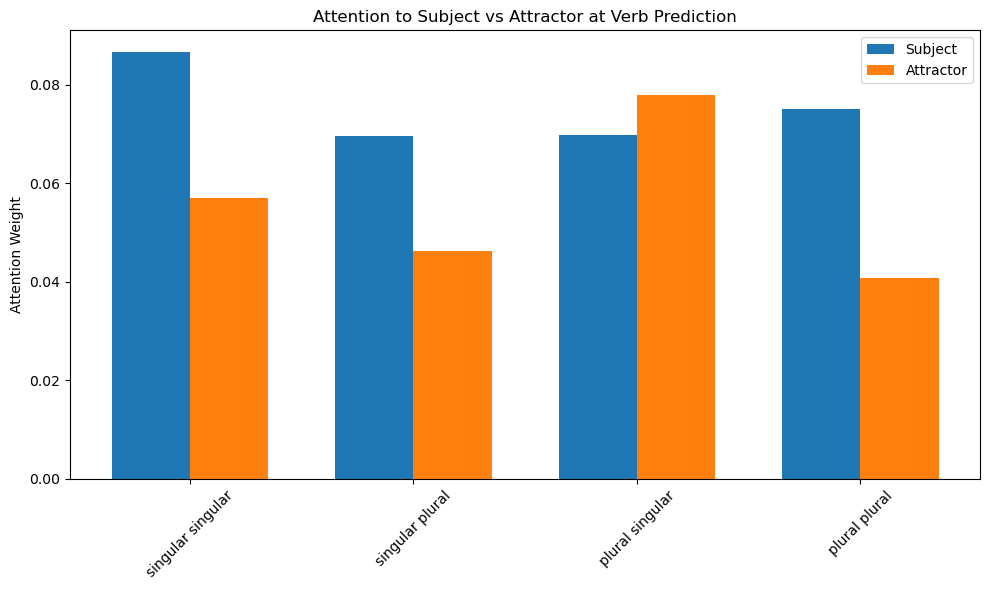

In [48]:
import matplotlib.pyplot as plt

conditions = list(attn_subject.keys())
subject_means = [np.median(attn_subject[c]) for c in conditions]
attractor_means = [np.median(attn_attractor[c]) for c in conditions]

x = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, subject_means, width, label='Subject')
ax.bar(x + width/2, attractor_means, width, label='Attractor')

ax.set_xticks(x)
ax.set_xticklabels(conditions, rotation=45)
ax.set_ylabel('Attention Weight')
ax.set_title('Attention to Subject vs Attractor at Verb Prediction')
ax.legend()

plt.tight_layout()
plt.show()


# Anaylzing values and feedforward layer

In [49]:
res, attention, attention_weights, sentences = evaluate_one_sample_per_condition(dataset, model, temp, None, collate_fn_nounpp)

In [51]:
len(attention)

4

In [52]:
sentences

{'singular singular': [['The',
   'athlete',
   'behind',
   'the',
   'bike',
   'observes']],
 'singular plural': [['The', 'athlete', 'behind', 'the', 'bikes', 'admires']],
 'plural singular': [['The',
   'athletes',
   'behind',
   'the',
   'bike',
   'encourage']],
 'plural plural': [['The', 'athletes', 'behind', 'the', 'bikes', 'criticize']]}

In [58]:
len(attention['singular singular'])

6

In [61]:
attention['singular singular'][4].shape

torch.Size([1, 650])

In [64]:
def plot_attention_values(attn_values, sentence, title):
    """
    Plot a heatmap of attention vector values per token.

    attn_values: list of torch tensors, each of shape (hidden_dim,)
    sentence: list of token strings
    title: plot title
    """
    attn_matrix_np = torch.stack(attn_values).squeeze().cpu().detach().numpy()  # Shape: (seq_len, hidden_dim)
    tokens = sentence[:attn_matrix_np.shape[0]]

    fig, ax = plt.subplots(figsize=(10, 6))

    # Use a diverging colormap for better visual distinction
    cax = ax.imshow(attn_matrix_np, aspect='auto', cmap='RdBu_r')

    ax.set_xticks(np.arange(attn_matrix_np.shape[1]))
    ax.set_yticks(np.arange(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=9)
    ax.set_xlabel('Hidden Dimension Index')
    ax.set_ylabel('Tokens')
    ax.set_title(title)

    fig.colorbar(cax, label='Attention Vector Value')
    plt.tight_layout()
    plt.show()


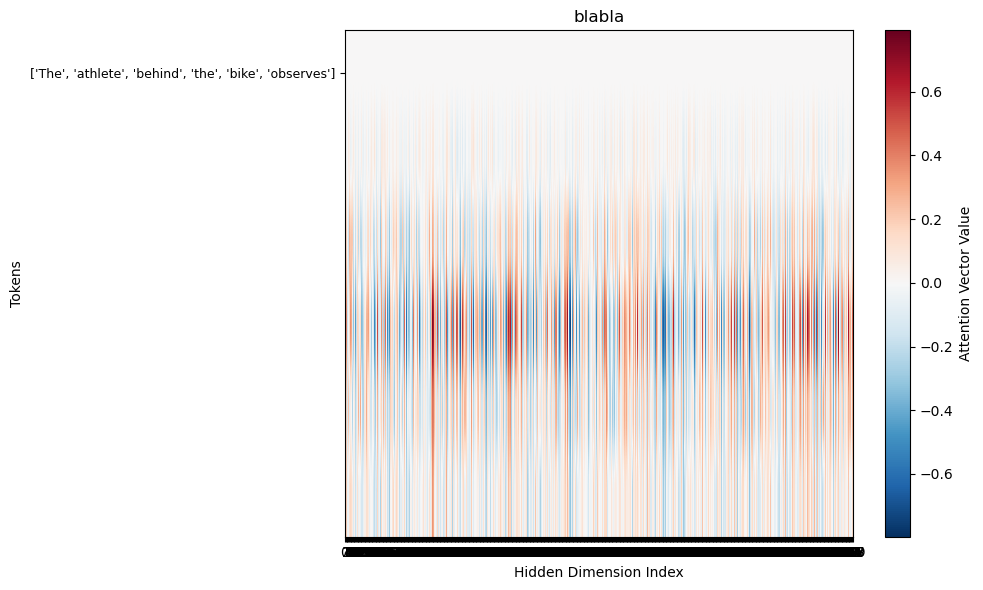

In [65]:
plot_attention_values(attention['singular singular'], sentences['singular singular'], 'blabla')

In [66]:
attn_matrix_np = torch.stack(attention['singular singular']).squeeze().cpu().detach().numpy()

In [67]:
attn_matrix_np.shape

(6, 650)